# Electricity Demand Baselines

Phase 3A evaluates deterministic baselines only. Protocol A and Protocol B use different information sets and are never combined into one ranking.


## 1. Load Dataset


In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "src").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate project root containing src/")

ROOT = find_project_root(Path.cwd())
DATA = ROOT / "data/electricity/australian_electricity_demand_dataset.tsf"
RESULTS = ROOT / "results/electricity"
RESULTS.mkdir(parents=True, exist_ok=True)
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from src.metrics import mae, rmse, mape, smape, mase

def load_tsf(path):
    metadata, attributes, rows = {}, [], []
    with Path(path).open(encoding="utf-8") as f:
        for raw in f:
            line=raw.strip()
            if not line or line.startswith("#"): continue
            if line.startswith("@attribute"):
                _,name,kind=line.split(maxsplit=2); attributes.append((name,kind))
            elif line.startswith("@") and not line.startswith("@data"):
                key,val=line[1:].split(maxsplit=1); metadata[key]=val
            elif not line.startswith("@"):
                parts=line.split(":",len(attributes)); row=dict(zip((x[0] for x in attributes),parts[:-1])); row["series_value"]=np.fromstring(parts[-1],sep=","); rows.append(row)
    return pd.DataFrame(rows),metadata

raw, metadata = load_tsf(DATA)
display(pd.Series(metadata).to_frame("value"))


,value
relation,Aus_Electricity_Demand
frequency,half_hourly
missing,false
equallength,false


## 2. Reconstruct South Australia T4


In [2]:
selected=raw[(raw.series_name=="T4") & (raw.state=="SA")]
assert len(selected)==1
row=selected.iloc[0]
start=pd.to_datetime(row.start_timestamp,format="%Y-%m-%d %H-%M-%S")
idx=pd.date_range(start,periods=len(row.series_value),freq="30min")
y=pd.Series(row.series_value,index=idx,name="Demand")
assert row.state=="SA" and row.series_name=="T4"
assert len(y)==230_784 and pd.infer_freq(y.index)=="30min"
assert not y.isna().any() and not y.index.duplicated().any() and y.index.is_monotonic_increasing
print(row.series_name,row.state,y.index.min(),y.index.max(),len(y),pd.infer_freq(y.index))


T4 SA 2002-01-01 00:00:00 2015-03-01 23:30:00 230784 30min


## 3. Frozen Data Partitions


In [3]:
dev=y.loc["2002-01-01 00:00":"2011-06-23 23:30"]
validation=y.loc["2011-06-24 00:00":"2012-07-12 23:30"]
pretest=y.loc["2002-01-01 00:00":"2012-07-12 23:30"]
test=y.loc["2012-07-13 00:00":"2015-03-01 23:30"]
assert (len(dev),len(validation),len(pretest),len(test))==(166128,18480,184608,46176)
assert dev.index[-1] < validation.index[0] and validation.index[-1] < test.index[0]
assert test.index[0].time()==pd.Timestamp("00:00").time()
display(pd.DataFrame({"Partition":["Development","Validation","Pre-test","Final test"],"Start":[x.index[0] for x in [dev,validation,pretest,test]],"End":[x.index[-1] for x in [dev,validation,pretest,test]],"N":[len(x) for x in [dev,validation,pretest,test]]}))


,Partition,Start,End,N
0,Development,2002-01-01,2011-06-23 23:30:00,166128
1,Validation,2011-06-24,2012-07-12 23:30:00,18480
2,Pre-test,2002-01-01,2012-07-12 23:30:00,184608
3,Final test,2012-07-13,2015-03-01 23:30:00,46176


## 4. MASE-48 Scaling


In [4]:
def mase_scale(train,m=48):
    a=np.asarray(train,float); return float(np.mean(np.abs(a[m:]-a[:-m])))
dev_scale=mase_scale(dev,48); final_scale=mase_scale(pretest,48)
print(f"Development MASE-48 denominator: {dev_scale:.12f}")
print(f"Final pre-test MASE-48 denominator: {final_scale:.12f}")
assert np.isclose(mase(validation,validation,dev,48),0.0)


Development MASE-48 denominator: 117.734228078432
Final pre-test MASE-48 denominator: 117.057971280678


## 5. Validation-Only Moving Average Selection


In [5]:
def metric_row(actual,pred,scale):
    return {"MAE":mae(actual,pred),"RMSE":rmse(actual,pred),"MAPE":mape(actual,pred),"sMAPE":smape(actual,pred),"MASE_48":mae(actual,pred)/scale}

candidates=[48,96,336]
val_rows=[]
for w in candidates:
    pred=y.rolling(w).mean().shift(1).loc[validation.index]
    assert pred.notna().all()
    val_rows.append({"Window":w,**metric_row(validation,pred,dev_scale)})
val_metrics=pd.DataFrame(val_rows).sort_values("MASE_48").reset_index(drop=True)
display(val_metrics)
selected_window=int(val_metrics.iloc[0].Window)
print("Frozen selected moving-average window:",selected_window)
assert selected_window in candidates


,Window,MAE,RMSE,MAPE,sMAPE,MASE_48
0,48,182.433952,229.910373,14.881769,14.209181,1.549540
1,96,197.175811,246.053874,16.061527,15.382465,1.674754
2,336,209.414697,261.137362,17.016459,16.301675,1.778707


Frozen selected moving-average window: 48


## 6. Protocol A — Rolling One-Step Baselines


In [6]:
pa=pd.DataFrame(index=test.index)
pa["Actual"]=test
pa["Naive"]=y.shift(1).loc[test.index]
pa["Daily_Seasonal_Naive"]=y.shift(48).loc[test.index]
pa["Weekly_Seasonal_Naive"]=y.shift(336).loc[test.index]
pa["Moving_Average"]=y.rolling(selected_window).mean().shift(1).loc[test.index]
pa.index.name="Timestamp"
pa.reset_index().to_csv(RESULTS/"protocol_a_baseline_forecasts.csv",index=False,date_format="%Y-%m-%d %H:%M:%S")
print(pa.shape, RESULTS/"protocol_a_baseline_forecasts.csv")


(46176, 5) E:\Re_Sc_AM\TimeSeriesFoundationModels\results\electricity\protocol_a_baseline_forecasts.csv


## 7. Protocol A Metrics


In [7]:
models=["Naive","Daily_Seasonal_Naive","Weekly_Seasonal_Naive","Moving_Average"]
pa_metrics=pd.DataFrame([{"Model":m,**metric_row(pa.Actual,pa[m],final_scale)} for m in models]).sort_values("MASE_48").reset_index(drop=True)
display(pa_metrics)


,Model,MAE,RMSE,MAPE,sMAPE,MASE_48
0,Naive,42.271787,58.272152,3.465892,3.486887,0.361118
1,Daily_Seasonal_Naive,129.416180,200.442098,10.640790,10.471882,1.105573
2,Weekly_Seasonal_Naive,153.210769,267.161682,11.999432,11.662290,1.308845
3,Moving_Average,179.122226,227.658772,15.243380,14.674740,1.530201


## 8. Protocol A Diagnostics


,Model,N,Aligned,Missing,Finite,Min,Max,Prediction_Std,Actual_Std,Correlation
0,Naive,46176,True,0,True,488.835380,2937.103248,296.784217,296.781312,0.980724
1,Daily_Seasonal_Naive,46176,True,0,True,488.835380,2937.103248,296.759665,296.781312,0.771906
2,Weekly_Seasonal_Naive,46176,True,0,True,488.835380,2937.103248,297.198511,296.781312,0.595388
3,Moving_Average,46176,True,0,True,746.763189,2326.145081,207.205877,296.781312,0.643825


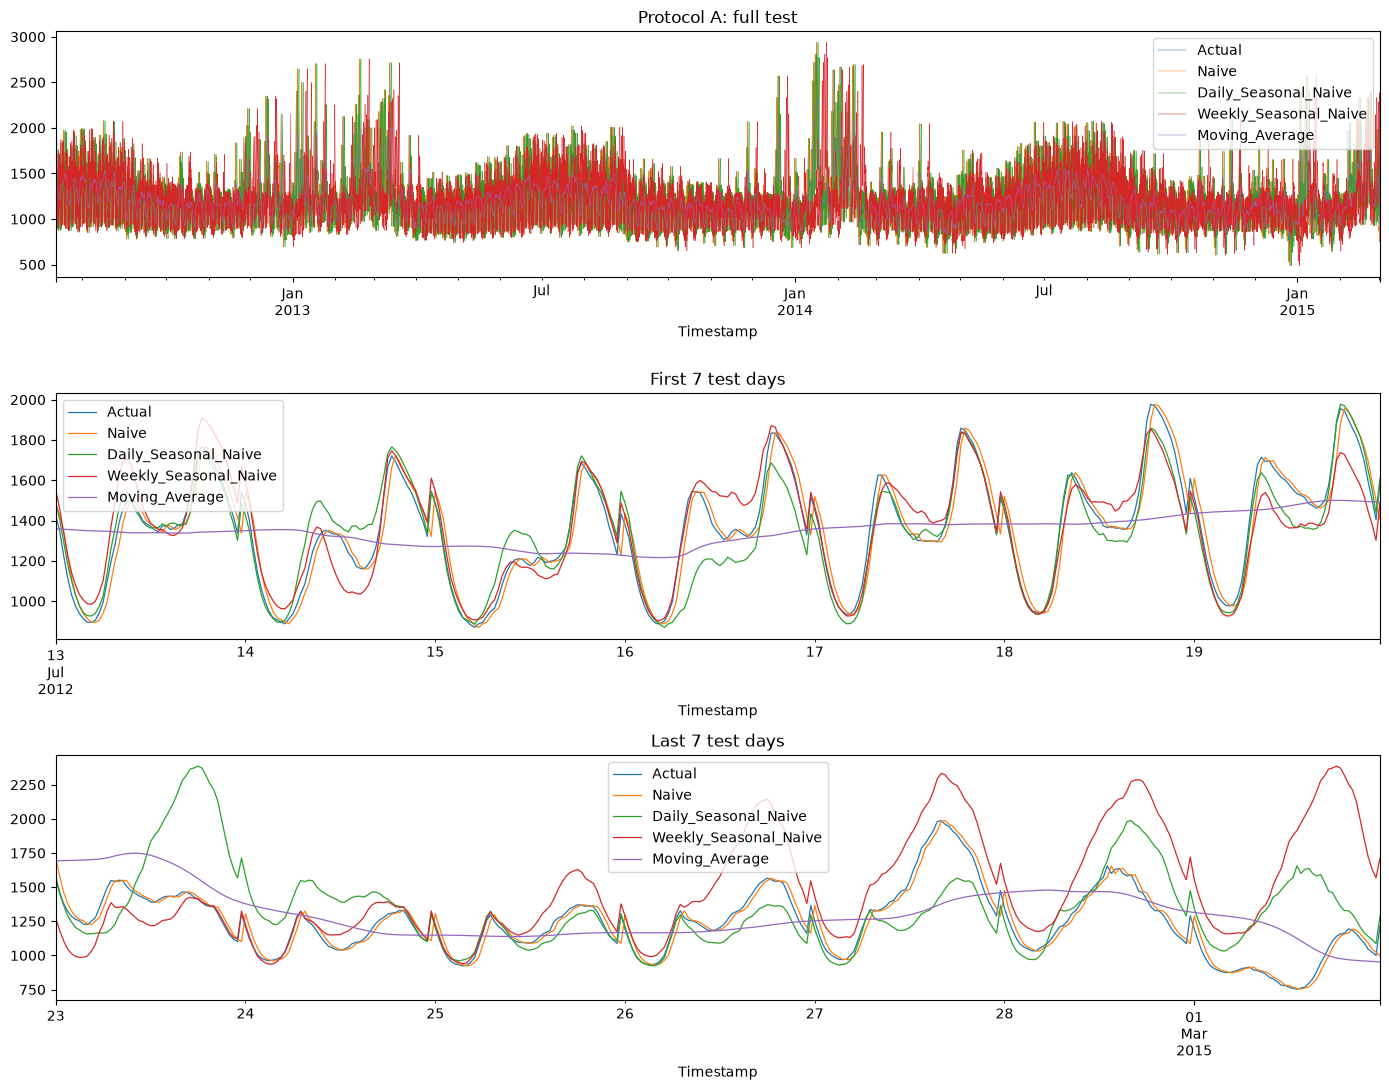

In [8]:
pa_diag=pd.DataFrame([{"Model":m,"N":len(pa[m]),"Aligned":pa[m].index.equals(pa.Actual.index),"Missing":int(pa[m].isna().sum()),"Finite":bool(np.isfinite(pa[m]).all()),"Min":pa[m].min(),"Max":pa[m].max(),"Prediction_Std":pa[m].std(),"Actual_Std":pa.Actual.std(),"Correlation":pa[m].corr(pa.Actual)} for m in models])
display(pa_diag)
fig,axs=plt.subplots(3,1,figsize=(14,11)); pa[["Actual"]+models].plot(ax=axs[0],lw=.35,title="Protocol A: full test"); pa.iloc[:336][["Actual"]+models].plot(ax=axs[1],lw=.9,title="First 7 test days"); pa.iloc[-336:][["Actual"]+models].plot(ax=axs[2],lw=.9,title="Last 7 test days"); plt.tight_layout(); plt.show()


## 9. Protocol B — Day-Ahead Baselines


In [9]:
values=y.to_numpy(); positions=pd.Series(np.arange(len(y)),index=y.index)
origins=test.index[::48]; assert len(origins)==962
records=[]
for origin in origins:
    p=int(positions.loc[origin]); actual=values[p:p+48]
    last=float(values[p-1]); naive=np.repeat(last,48)
    daily=values[p-48:p].copy(); weekly=values[p-336:p-288].copy()
    history=list(values[p-selected_window:p].astype(float)); moving=[]
    for _ in range(48):
        pred=float(np.mean(history[-selected_window:])); moving.append(pred); history.append(pred)
    for h in range(48):
        records.append({"Origin":origin,"Timestamp":y.index[p+h],"Horizon":h+1,"Actual":actual[h],"Naive":naive[h],"Daily_Seasonal_Naive":daily[h],"Weekly_Seasonal_Naive":weekly[h],"Moving_Average":moving[h]})
pb=pd.DataFrame(records)
pb.to_csv(RESULTS/"protocol_b_baseline_forecasts.csv",index=False,date_format="%Y-%m-%d %H:%M:%S")
print(pb.shape,pb.Origin.nunique(),RESULTS/"protocol_b_baseline_forecasts.csv")


(46176, 8) 962 E:\Re_Sc_AM\TimeSeriesFoundationModels\results\electricity\protocol_b_baseline_forecasts.csv


## 10. Protocol B Overall Metrics


In [10]:
pb_saved=pd.read_csv(RESULTS/"protocol_b_baseline_forecasts.csv",parse_dates=["Origin","Timestamp"])
pb_metrics=pd.DataFrame([{"Model":m,**metric_row(pb_saved.Actual,pb_saved[m],final_scale)} for m in models]).sort_values("MASE_48").reset_index(drop=True)
display(pb_metrics)


,Model,MAE,RMSE,MAPE,sMAPE,MASE_48
0,Daily_Seasonal_Naive,129.416180,200.442098,10.640790,10.471882,1.105573
1,Weekly_Seasonal_Naive,153.210769,267.161682,11.999432,11.662290,1.308845
2,Moving_Average,203.199277,260.260560,17.756404,16.456455,1.735886
3,Naive,243.838179,301.681217,22.907776,19.738307,2.083055


## 11. Protocol B Horizon-Specific Metrics


In [11]:
hrows=[]
for m in models:
    for h,g in pb_saved.groupby("Horizon",sort=True): hrows.append({"Model":m,"Horizon":int(h),**metric_row(g.Actual,g[m],final_scale)})
hmetrics=pd.DataFrame(hrows)[["Model","Horizon","MAE","RMSE","MAPE","sMAPE","MASE_48"]]
hmetrics.to_csv(RESULTS/"protocol_b_horizon_metrics.csv",index=False)
groups=pd.cut(pb_saved.Horizon,bins=[0,12,24,48],labels=["H1-H12","H13-H24","H25-H48"])
summary=[]
for m in models:
    for label,g in pb_saved.groupby(groups,observed=True): summary.append({"Model":m,"Horizon_Group":str(label),**metric_row(g.Actual,g[m],final_scale)})
hsummary=pd.DataFrame(summary)
display(hsummary)
display(hmetrics.groupby("Model").agg(MAE_h1=("MAE","first"),MAE_h48=("MAE","last"),MASE_h1=("MASE_48","first"),MASE_h48=("MASE_48","last")).reset_index())


,Model,Horizon_Group,MAE,RMSE,MAPE,sMAPE,MASE_48
0,Naive,H1-H12,359.087641,388.670551,37.804211,30.830382,3.067605
1,Naive,H13-H24,215.441741,271.341735,21.129536,17.959989,1.840470
2,Naive,H25-H48,200.411667,263.965047,16.348678,15.081428,1.712072
3,Daily_Seasonal_Naive,H1-H12,48.216427,73.257135,4.766421,4.725521,0.411902
4,Daily_Seasonal_Naive,H13-H24,160.458196,222.619495,13.906038,13.829614,1.370758
5,Daily_Seasonal_Naive,H25-H48,154.495048,229.980532,11.945350,11.666196,1.319817
6,Weekly_Seasonal_Naive,H1-H12,66.078200,110.431954,6.348350,6.298561,0.564491
7,Weekly_Seasonal_Naive,H13-H24,142.601768,235.971916,11.720671,11.452088,1.218215
8,Weekly_Seasonal_Naive,H25-H48,202.081554,329.866258,14.964353,14.449255,1.726337
9,Moving_Average,H1-H12,245.290853,295.889729,25.172805,21.552524,2.095465


,Model,MAE_h1,MAE_h48,MASE_h1,MASE_h48
0,Daily_Seasonal_Naive,51.509173,59.518156,0.440031,0.508450
1,Moving_Average,124.372698,160.509606,1.062488,1.371198
2,Naive,79.901836,59.518156,0.682583,0.508450
3,Weekly_Seasonal_Naive,78.519120,90.288762,0.670771,0.771317


## 12. Day-Ahead Diagnostics


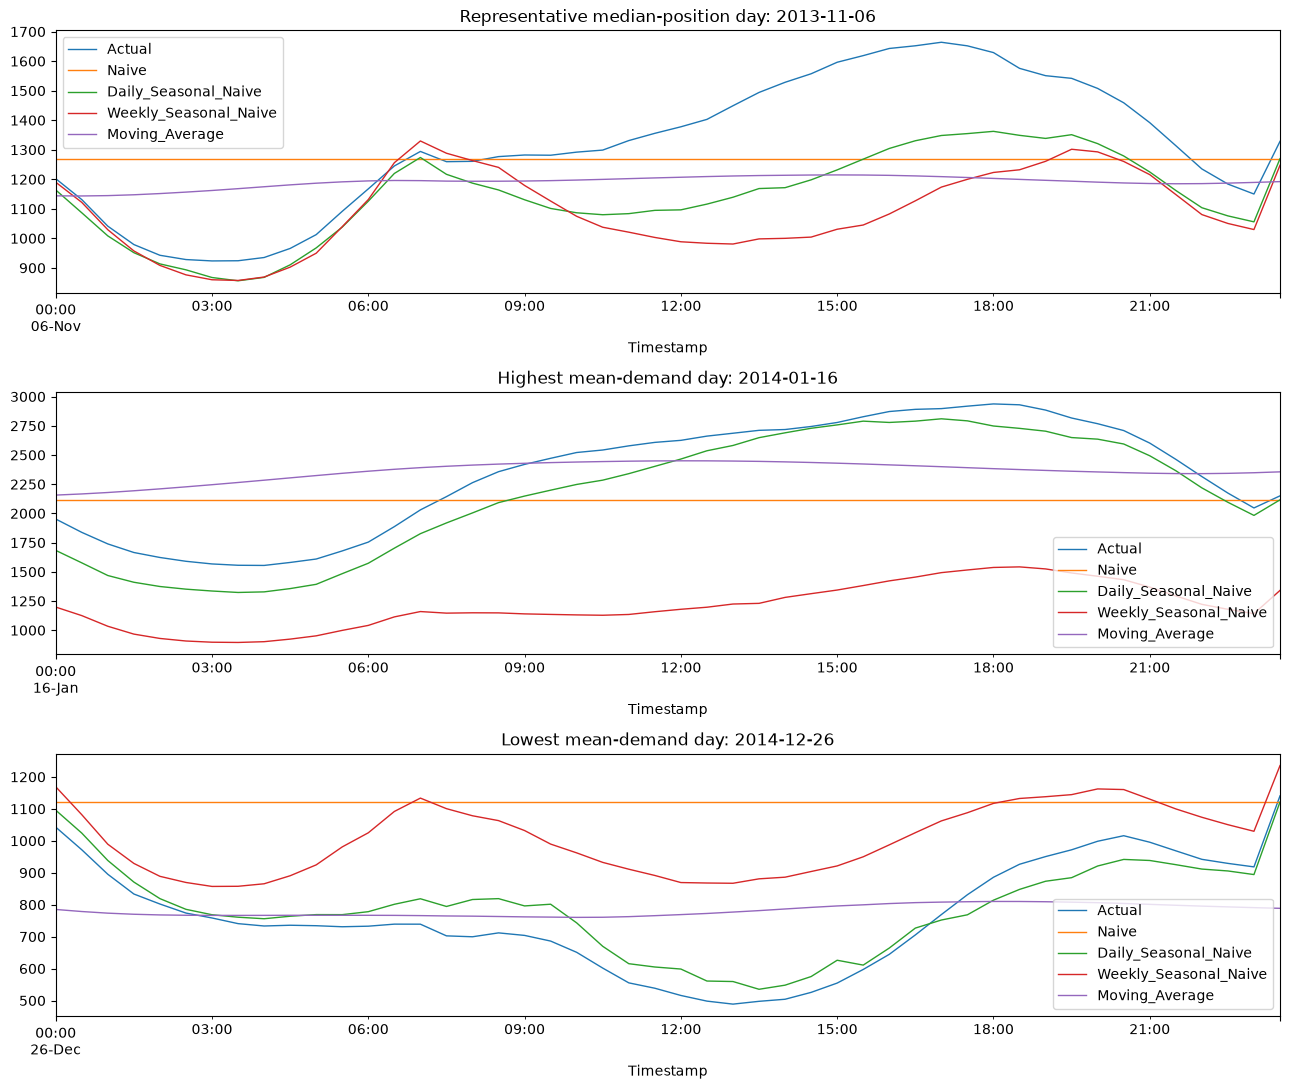

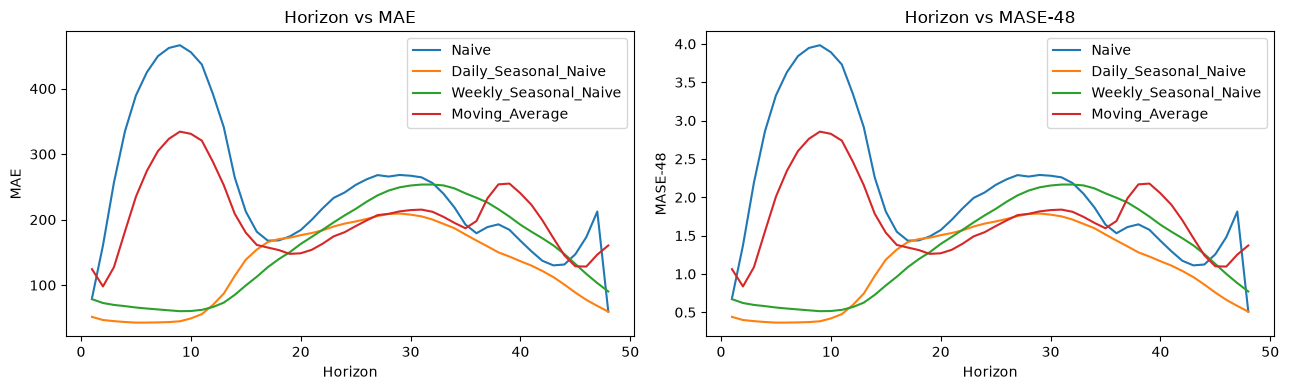

Demand-defined days: {'representative': '2013-11-06 00:00:00', 'high': '2014-01-16 00:00:00', 'low': '2014-12-26 00:00:00'}


In [12]:
daily_mean=pb_saved.groupby("Origin").Actual.mean(); representative=daily_mean.index[len(daily_mean)//2]; high=daily_mean.idxmax(); low=daily_mean.idxmin()
fig,axs=plt.subplots(3,1,figsize=(13,11))
for ax,o,title in zip(axs,[representative,high,low],["Representative median-position day","Highest mean-demand day","Lowest mean-demand day"]):
    g=pb_saved[pb_saved.Origin==o]; g.plot(x="Timestamp",y=["Actual"]+models,ax=ax,title=f"{title}: {o.date()}",lw=1)
plt.tight_layout(); plt.show()
fig,axs=plt.subplots(1,2,figsize=(13,4));
for m in models:
    g=hmetrics[hmetrics.Model==m]; axs[0].plot(g.Horizon,g.MAE,label=m); axs[1].plot(g.Horizon,g.MASE_48,label=m)
axs[0].set(title="Horizon vs MAE",xlabel="Horizon",ylabel="MAE"); axs[1].set(title="Horizon vs MASE-48",xlabel="Horizon",ylabel="MASE-48"); axs[0].legend(); axs[1].legend(); plt.tight_layout(); plt.show()
print("Demand-defined days:",{"representative":str(representative),"high":str(high),"low":str(low)})


## 13. Baseline Comparison


In [13]:
print("Best Protocol A baseline:",pa_metrics.iloc[0].Model,"MASE-48",pa_metrics.iloc[0].MASE_48)
print("Best Protocol B baseline:",pb_metrics.iloc[0].Model,"MASE-48",pb_metrics.iloc[0].MASE_48)
display(pa_metrics.assign(Protocol="A rolling one-step"))
display(pb_metrics.assign(Protocol="B day-ahead"))


Best Protocol A baseline: Naive MASE-48 0.3611184013957037
Best Protocol B baseline: Daily_Seasonal_Naive MASE-48 1.105573404106659


,Model,MAE,RMSE,MAPE,sMAPE,MASE_48,Protocol
0,Naive,42.271787,58.272152,3.465892,3.486887,0.361118,A rolling one-step
1,Daily_Seasonal_Naive,129.416180,200.442098,10.640790,10.471882,1.105573,A rolling one-step
2,Weekly_Seasonal_Naive,153.210769,267.161682,11.999432,11.662290,1.308845,A rolling one-step
3,Moving_Average,179.122226,227.658772,15.243380,14.674740,1.530201,A rolling one-step


,Model,MAE,RMSE,MAPE,sMAPE,MASE_48,Protocol
0,Daily_Seasonal_Naive,129.416180,200.442098,10.640790,10.471882,1.105573,B day-ahead
1,Weekly_Seasonal_Naive,153.210769,267.161682,11.999432,11.662290,1.308845,B day-ahead
2,Moving_Average,203.199277,260.260560,17.756404,16.456455,1.735886,B day-ahead
3,Naive,243.838179,301.681217,22.907776,19.738307,2.083055,B day-ahead


## 14. Key Findings


In [14]:
print(f"- Moving-average window {selected_window} was selected solely by validation MASE-48.")
print(f"- Protocol A winner: {pa_metrics.iloc[0].Model}; lag-1 persistence is evaluated rather than presumed weak.")
print(f"- Protocol B winner: {pb_metrics.iloc[0].Model}; its ranking is separate from Protocol A.")
na_h=hmetrics[hmetrics.Model=="Naive"].set_index("Horizon"); print(f"- Protocol B persistence MAE changes from {na_h.loc[1,'MAE']:.3f} at h=1 to {na_h.loc[48,'MAE']:.3f} at h=48.")
print("- No conclusion about advanced-model superiority is made in this phase.")


- Moving-average window 48 was selected solely by validation MASE-48.
- Protocol A winner: Naive; lag-1 persistence is evaluated rather than presumed weak.
- Protocol B winner: Daily_Seasonal_Naive; its ranking is separate from Protocol A.
- Protocol B persistence MAE changes from 79.902 at h=1 to 59.518 at h=48.
- No conclusion about advanced-model superiority is made in this phase.


## 15. Validation Checks


In [15]:
pa_saved=pd.read_csv(RESULTS/"protocol_a_baseline_forecasts.csv",parse_dates=["Timestamp"])
def verify_recursive_moving_average():
    for origin,g in pb_saved.groupby("Origin",sort=True):
        p=int(positions.loc[origin]); history=list(values[p-selected_window:p].astype(float)); expected=[]
        for _ in range(48):
            pred=float(np.mean(history[-selected_window:])); expected.append(pred); history.append(pred)
        if not np.allclose(g.Moving_Average.to_numpy(),expected): return False
    return True
recursive_ma_verified=verify_recursive_moving_average()
checks={
"T4 metadata selection":row.series_name=="T4" and row.state=="SA",
"Frozen partitions":(len(dev),len(validation),len(test))==(166128,18480,46176),
"Protocol A shape":pa_saved.shape==(46176,6),
"Protocol A unique sorted timestamps":pa_saved.Timestamp.is_unique and pa_saved.Timestamp.is_monotonic_increasing,
"Protocol A no missing / finite":not pa_saved.isna().any().any() and np.isfinite(pa_saved[models].to_numpy()).all(),
"A Naive equals lag 1":np.allclose(pa_saved.Naive,y.shift(1).loc[test.index]),
"A Daily equals lag 48":np.allclose(pa_saved.Daily_Seasonal_Naive,y.shift(48).loc[test.index]),
"A Weekly equals lag 336":np.allclose(pa_saved.Weekly_Seasonal_Naive,y.shift(336).loc[test.index]),
"A Moving Average is prior-only":np.allclose(pa_saved.Moving_Average,y.rolling(selected_window).mean().shift(1).loc[test.index]),
"Protocol B shape":pb_saved.shape==(46176,8),
"Protocol B 962 origins":pb_saved.Origin.nunique()==962,
"Protocol B 48 rows each":pb_saved.groupby("Origin").size().eq(48).all(),
"Protocol B horizons 1..48":pb_saved.groupby("Origin").Horizon.apply(lambda z:z.tolist()==list(range(1,49))).all(),
"Protocol B unique sorted timestamps":pb_saved.Timestamp.is_unique and pb_saved.Timestamp.is_monotonic_increasing,
"Protocol B persistence constant":pb_saved.groupby("Origin").Naive.nunique().eq(1).all(),
"Protocol B daily previous slots":all(np.allclose(g.Daily_Seasonal_Naive,values[int(positions.loc[o])-48:int(positions.loc[o])]) for o,g in pb_saved.groupby("Origin")),
"Protocol B weekly previous slots":all(np.allclose(g.Weekly_Seasonal_Naive,values[int(positions.loc[o])-336:int(positions.loc[o])-288]) for o,g in pb_saved.groupby("Origin")),
"Protocol B recursive MA":recursive_ma_verified,
"Protocol B no missing / finite":not pb_saved.isna().any().any() and np.isfinite(pb_saved[models].to_numpy()).all(),
"Final horizon inside test":pb_saved.Timestamp.max()==test.index.max(),
"Horizon metrics shape":hmetrics.shape==(4*48,7),
"Saved Protocol A metrics reproduce":all(np.isclose(metric_row(pa_saved.Actual,pa_saved[m],final_scale)["MASE_48"],pa_metrics.set_index("Model").loc[m,"MASE_48"]) for m in models),
"Saved Protocol B metrics reproduce":all(np.isclose(metric_row(pb_saved.Actual,pb_saved[m],final_scale)["MASE_48"],pb_metrics.set_index("Model").loc[m,"MASE_48"]) for m in models),
}
audit=pd.DataFrame({"Check":checks.keys(),"Pass/Fail":["PASS" if v else "FAIL" for v in checks.values()],"Evidence":[str(v) for v in checks.values()]})
display(audit); assert all(checks.values()); print("ALL CHECKS PASS")


,Check,Pass/Fail,Evidence
0,T4 metadata selection,PASS,True
1,Frozen partitions,PASS,True
2,Protocol A shape,PASS,True
3,Protocol A unique sorted timestamps,PASS,True
4,Protocol A no missing / finite,PASS,True
5,A Naive equals lag 1,PASS,True
6,A Daily equals lag 48,PASS,True
7,A Weekly equals lag 336,PASS,True
8,A Moving Average is prior-only,PASS,True
9,Protocol B shape,PASS,True


ALL CHECKS PASS
